In [21]:
import os
from pathlib import Path
import pickle as pkl
import sys

dirpath_root = Path().resolve().parents[1]
sys.path.append(str(dirpath_root))

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from numpy import log
from numpy import abs, angle, pi, real, imag, sqrt, max, min
import scipy.signal as sig
from scipy.ndimage import gaussian_filter1d, gaussian_filter

import analysis.ou_tuning.netpyne_res_parse_utils as parse_utils

In [22]:
def smooth(X, sm0=0, sm1=0):
    if (sm0 == 0) and (sm1 == 0):
        return X
    if (sm0 != 0) and (sm1 != 0):
        return gaussian_filter(X, (sm0, sm1))
    if (sm0 != 0) and (sm1 == 0):
        return gaussian_filter1d(X, sm0, axis=0)
    if (sm0 == 0) and (sm1 != 0):
        return gaussian_filter1d(X, sm1, axis=-1)
    
def get_pop_ylim(sim_res, pop_name):
    h = sim_res['simConfig']['sizeY']
    yy = sim_res['net']['pops'][pop_name]['tags']['ynormRange']
    return (yy[0] * h, yy[1] * h)


def fft_smart(x, t, fmax=None, axis=-1):
    f = np.fft.fftfreq(len(t), t[1] - t[0])
    y = np.fft.fft(x)
    mask = (f >= 0)
    if fmax:
        mask &= (f < fmax)
    idx = np.argwhere(mask).ravel()
    return f[idx], y.take(idx, axis=axis)

In [23]:
# Time limits to analyze
t_lim = (2, 10)

fpath_in = r'/ddn/niknovikov19/repo/A1_OUinp/exp_results/single_i_ou_subnet_state1_mech1_nosub_wmult_0.25/full_model_split_ee_conn_adj_csd/exp_adj2_t_13.0_15.0_eefrac_0.5/full_model_split_ee_conn_adj_csd_data.pkl'

# Reference channel
#ref_chan = None
ref_chan = 0

fmax = 150

# LFP or CSD
pow_type = 'lfp'
#pow_type = 'bipolar'
#pow_type = 'csd'

# Normalize each freq. power by its max. over channels
#pow_norm = 'none'
pow_norm = 'freq'
#pow_norm = 'band'

need_log = 0

need_reload = 0
need_plot_f = 0
need_plot_d = 1
need_plot_fd = 0
need_save = 1

# Smoothing window lengths
sm_f = 10
sm_d = 1

need_smooth = 1

# Frequency bands
fband_low = (10, 30)
#fband_high = (50, 150)
fband_high = (40, 100)

layer_groups = [(0, 950), (950, 1250), (1250, 2000)]
#layer_groups = [(0, 1000), (1000, 2000)]


# Load LFPs
with open(fpath_in, 'rb') as fid:
    sim_result = pkl.load(fid)    
lfp, tt, lfp_coords = parse_utils.get_lfp(sim_result)
tt /= 1000
#lfp = lfp.T
yy = lfp_coords[:, 1]

# Select time range
t_idx = np.argwhere(((tt >= t_lim[0]) & (tt <= t_lim[1]))).ravel()
tt = tt[t_idx]
lfp = lfp[:, t_idx]
X = lfp

# Get layer borders
#layer_yrange = {}
#for pop_name in sim_result['net']['pops']:
#    layer_yrange[pop_name] = get_pop_ylim(sim_result, pop_name)

# Re-reference
if ref_chan is not None:
    X -= X[ref_chan, :]

# Bipolar / CSD
if pow_type == 'bipolar':
    X = np.concatenate([X[0, None, :], X], axis=0)
    X = np.diff(X, n=1, axis=0)
if pow_type == 'csd':
    X = np.concatenate([X[0, None, :], X, X[-1, None, :]], axis=0)
    X = np.diff(X, n=2, axis=0)

In [24]:
# Spectral power
nt = len(tt)
h = sig.windows.hann(nt).reshape((1, nt))
ff, W = fft_smart(X * h, tt, fmax=fmax)
W = np.abs(W)

# Normalize each freq. power by its max. over channels
if pow_norm == 'freq':
    W /= W.max(axis=0)

Text(0.5, 1.0, 'lfp, ref=0, norm=freq, log=0, smooth=10')

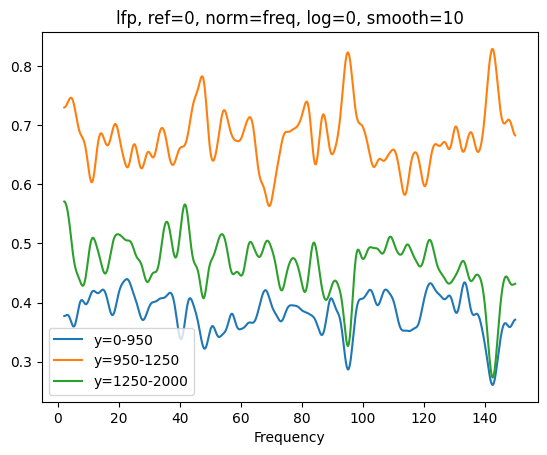

In [25]:
title_str = f'{pow_type}, ref={ref_chan}, norm={pow_norm}, log={need_log}'

f_lim = (2, 150)
f_mask = ((ff >= f_lim[0]) & (ff <= f_lim[1]))
W_ = W[:, f_mask]
ff_ = ff[f_mask]
plt.figure(111)
plt.clf()
for ylim in layer_groups:
    mask = (yy >= ylim[0]) & (yy <= ylim[1])
    w = W_[mask, :].mean(axis=0)
    if need_smooth:
        w = smooth(w, sm_f)
    if need_log:
        w = log(w)
    plt.plot(ff_, w, label=f'y={ylim[0]}-{ylim[1]}')
plt.legend()
plt.xlabel('Frequency')
sm_ = sm_f if need_smooth else 0
title_str_ = title_str + f', smooth={sm_}'
plt.title(title_str_)


Text(0.5, 1.0, 'lfp, ref=0, norm=freq, log=0, smooth=(10_1)')

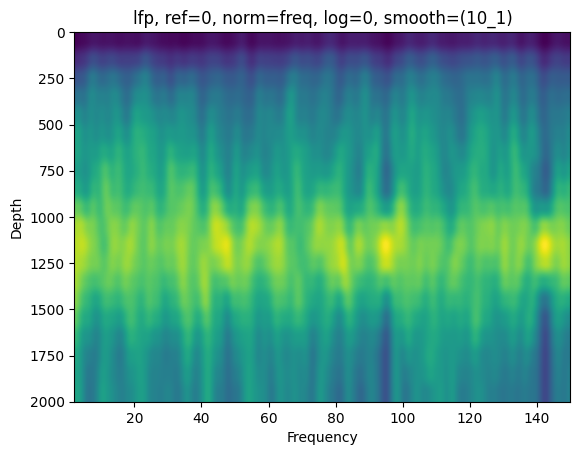

In [26]:
f_lim = (2, 150)
f_mask = ((ff >= f_lim[0]) & (ff <= f_lim[1]))
W_ = W[:, f_mask]
if need_smooth:
    W_ = smooth(W_, sm_d, sm_f)
if need_log:
    W_ = log(W_)    
plt.figure(111)
plt.clf()
ext = (ff[f_mask][0], ff[f_mask][-1], sim_result['simConfig']['sizeY'], 0)
plt.imshow(W_, aspect='auto', extent=ext, origin='upper')
#plot_layer_borders(ext[0], ext[1])
plt.xlabel('Frequency')
plt.ylabel('Depth')
sm_ = (sm_f, sm_d) if need_smooth else (0, 0)
title_str_ = title_str + f', smooth=({sm_[0]}_{sm_[1]})'
plt.title(title_str_)

NameError: name 'dirpath_out_d' is not defined

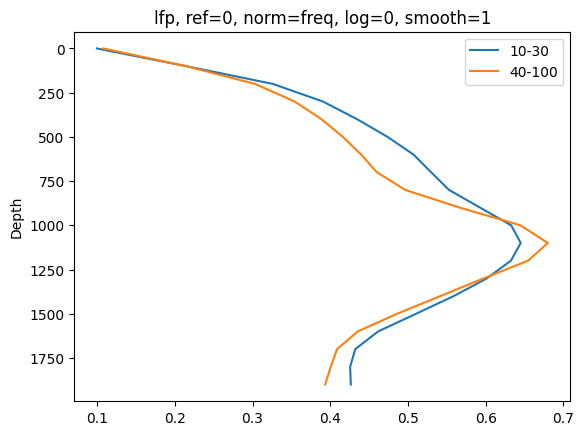

In [27]:

    
def plot_layer_borders(x0, x1, all_layers=True):
    if all_layers:
        pops_vis = ['IT2', 'IT3', 'IT5A', 'IT5B', 'IT6', 'ITP4']
    else:
        pops_vis = ['ITP4']
    for pop_name in pops_vis:
        yy_ = get_pop_ylim(sim_result, pop_name)
        if pop_name == 'ITP4':
            col = 'k'
        else:
            col = 'k'
        for n in [0, 1]:
            plt.plot([x0, x1], [yy_[n], yy_[n]], f'{col}--')

title_str = f'{pow_type}, ref={ref_chan}, norm={pow_norm}, log={need_log}'

if need_plot_f:
    f_lim = (2, 150)
    f_mask = ((ff >= f_lim[0]) & (ff <= f_lim[1]))
    W_ = W[:, f_mask]
    ff_ = ff[f_mask]
    plt.figure(111)
    plt.clf()
    for ylim in layer_groups:
        mask = (yy >= ylim[0]) & (yy <= ylim[1])
        w = W_[mask, :].mean(axis=0)
        if need_smooth:
            w = smooth(w, sm_f)
        if need_log:
            w = log(w)
        plt.plot(ff_, w, label=f'y={ylim[0]}-{ylim[1]}')
    plt.legend()
    plt.xlabel('Frequency')
    sm_ = sm_f if need_smooth else 0
    title_str_ = title_str + f', smooth={sm_}'
    plt.title(title_str_)
    if need_save:
        fname_out = title_str_.replace(', ', '_') + '.png'
        plt.savefig(dirpath_out_f / fname_out)

if need_plot_d:
    plt.figure(111)
    plt.clf()
    fbands = [fband_low, fband_high]
    for fband in fbands:
        w = W[:, (ff >= fband[0]) & (ff <= fband[1])].mean(axis=1)
        if pow_norm == 'band':
            w /= w.max()
        if need_smooth:
            w = smooth(w, sm_d)
        if need_log:
            w = log(w)
        plt.plot(w, yy, label=f'{fband[0]}-{fband[1]}')
        #wmin = np.minimum(min(wlow), min(whigh))
        #wmax = np.maximum(max(wlow), max(whigh))
        #plot_layer_borders(0, 1, all_layers=False)
        #plot_layer_borders(0, max(w), all_layers=False)
    plt.gca().invert_yaxis()
    plt.legend()
    plt.ylabel('Depth')
    sm_ = sm_d if need_smooth else 0
    title_str_ = title_str + f', smooth={sm_}'
    plt.title(title_str_)
    if need_save:
        fname_out = title_str_.replace(', ', '_') + '.png'
        plt.savefig(dirpath_out_d / fname_out)

if need_plot_fd:
    f_lim = (2, 150)
    f_mask = ((ff >= f_lim[0]) & (ff <= f_lim[1]))
    W_ = W[:, f_mask]
    if need_smooth:
        W_ = smooth(W_, sm_d, sm_f)
    if need_log:
        W_ = log(W_)    
    plt.figure(111)
    plt.clf()
    ext = (ff[f_mask][0], ff[f_mask][-1], sim_result['simConfig']['sizeY'], 0)
    plt.imshow(W_, aspect='auto', extent=ext, origin='upper')
    plot_layer_borders(ext[0], ext[1])
    plt.xlabel('Frequency')
    plt.ylabel('Depth')
    sm_ = (sm_f, sm_d) if need_smooth else (0, 0)
    title_str_ = title_str + f', smooth=({sm_[0]}_{sm_[1]})'
    plt.title(title_str_)
    if need_save:
        fname_out = title_str_.replace(', ', '_') + '.png'
        plt.savefig(dirpath_out_df / fname_out)
